<div align="center">

<img src="https://s3.amazonaws.com/files.pucp.edu.pe/pucp-general/img-header/logo-pucp-new.svg" alt="Pontificia Universidad Católica del Perú">

<br><br>

## Pontificia Universidad Católica del Perú  

### Deep Learning con Python  

<br>

## Semana 2 — Tarea 2

### Comparando modelos con Tensorflow

</div>

---

Objetivo de este notebook:

- Utilizar tensorflow para construir modelos de Deep Learning

- Comparar la performance de los modelos variando parametros

- Compara la implementacion de una CNN con redes MLP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report

In [2]:
from PIL import Image
import random


## Dataset utilizado: Fashion-MNIST

En esta experiencia utilizaremos el dataset **Fashion-MNIST**, uno de los conjuntos de datos más utilizados para experimentos introductorios en **Machine Learning y Deep Learning**.  

Este dataset fue propuesto como una alternativa más desafiante al clásico **MNIST**, el cual contiene dígitos escritos a mano. En cambio, **Fashion-MNIST contiene imágenes de prendas de vestir**, lo que introduce mayor variabilidad visual y hace el problema de clasificación ligeramente más complejo.

### Características del dataset

- Contiene **70,000 imágenes en escala de grises**
- Cada imagen tiene un tamaño de **28 × 28 píxeles**
- El dataset está dividido en:
  - **60,000 imágenes de entrenamiento**
  - **10,000 imágenes de prueba**
- Existen **10 clases de ropa**

Las clases presentes en el dataset son:

| Label | Clase |
|------|------|
| 0 | T-shirt / top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Cada imagen representa una prenda centrada sobre un fondo uniforme, lo cual permite concentrar el aprendizaje del modelo en **patrones visuales relevantes como bordes, formas y texturas**.

En esta tarea utilizaremos este dataset para:

- Entrenar **redes neuronales tipo MLP (Multi-Layer Perceptron)**
- Analizar el efecto de **técnicas de regularización** como **L2** y **Dropout**
- Comparar el desempeño de estas arquitecturas con una **Convolutional Neural Network (CNN)**

---

### Carga del dataset

A continuación se muestra la celda de código para **descargar y cargar el dataset directamente desde TensorFlow**.

Por favor, **ejecutar la siguiente celda** para importar el dataset que se utilizará en el resto del notebook.

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(class_names)

Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Visualización del dataset

Antes de comenzar con el entrenamiento de los modelos, es importante **explorar visualmente el dataset** para comprender mejor el tipo de imágenes con las que trabajaremos.

En esta sección se solicita **visualizar ejemplos aleatorios del dataset Fashion-MNIST**.

### Instrucciones

En la siguiente celda de código deberán:

- Seleccionar **9 imágenes aleatorias** del conjunto de entrenamiento.
- Mostrar las imágenes utilizando **Matplotlib**.
- Organizar las imágenes en una figura de **3 × 3**.
- Mostrar también el **nombre de la clase correspondiente** a cada imagen.

Esto permitirá observar distintos ejemplos de prendas presentes en el dataset y verificar que los datos fueron cargados correctamente.

Sugerencias:

- Utilizar `numpy` para seleccionar índices aleatorios.
- Utilizar `plt.subplot()` para organizar la figura en una cuadrícula **3 × 3**.
- Usar `cmap="gray"` al mostrar las imágenes.
- Desactivar los ejes con `plt.axis("off")`.

---

👉 **Implementar el código en la siguiente celda.**

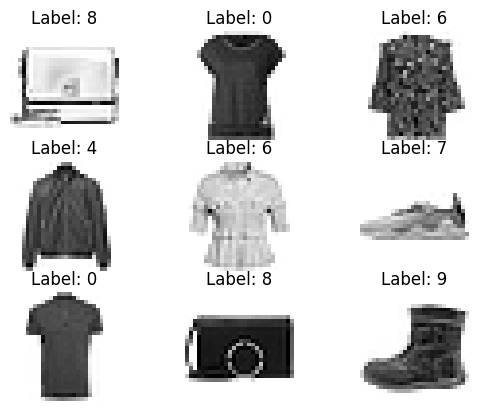

In [4]:
plt.figure()
for i in range(9):
    index = random.randint(0, len(X_train))
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[index], cmap=plt.cm.binary)
    plt.title(f"Label: {y_train[index]}")
    plt.axis('off')
plt.show()

## Preprocesamiento de los datos

Antes de entrenar los modelos es necesario realizar algunos pasos de **preprocesamiento** sobre el dataset.

En esta sección se realizarán dos operaciones importantes:

1. **Normalización de los píxeles**
2. **Reformateo de las imágenes (reshape)** para utilizarlas en redes MLP

---

### 1. Normalización de los datos

Las imágenes del dataset están representadas con valores de píxel en el rango:

0 – 255

Esto se debe a que cada píxel está almacenado como un **entero de 8 bits**.

Para facilitar el entrenamiento de redes neuronales, es recomendable **escalar los datos a un rango entre 0 y 1**. Esto se logra dividiendo todos los valores de píxel entre **255**.

La normalización ayuda a:

- Estabilizar el entrenamiento
- Mejorar la convergencia del optimizador
- Evitar que algunas variables tengan magnitudes mucho mayores que otras

Por lo tanto, los datos deben transformarse de:

0 – 255 → 0 – 1


---

### 2. Reformateo de las imágenes (reshape)

Las imágenes de **Fashion-MNIST** tienen originalmente la forma:

(28, 28)


Es decir, cada imagen es una **matriz de píxeles**.

Sin embargo, las redes **MLP (Multi-Layer Perceptron)** esperan como entrada **vectores unidimensionales**. Por esta razón, cada imagen debe convertirse a un vector de tamaño:

28 × 28 = 784

Después del reshape, el conjunto de entrenamiento debería tener dimensiones:

(60000, 784)

y el conjunto de prueba:

(10000, 784)


---

### Verificación

Después de realizar la normalización y el reshape, se solicita **imprimir las dimensiones de los datasets** para verificar que la transformación fue realizada correctamente.

---

### ⚠️ Advertencia importante

Esta celda debe ejecutarse **solo una vez**.

Si se ejecuta nuevamente, los datos ya transformados podrían volver a aplicarse al reshape, lo cual generará **dimensiones incorrectas o errores**.

En caso de ejecutar esta celda múltiples veces por error, se recomienda **reiniciar el kernel y ejecutar el notebook nuevamente desde el inicio** para evitar inconsistencias en los datos.

---

👉 Implementar el código correspondiente en la siguiente celda.

Aplicando normalización de datos

In [5]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [8]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


Aplicando reformateo en la imágenes

In [9]:
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(X_test.shape[0], 28*28)

print(X_train.shape)
print(X_test.shape)


(60000, 784)
(10000, 784)


Aplicando one-hot encoding

In [10]:
y_train[120]

np.uint8(5)

In [11]:
y_train= tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)

print(X_train.shape)
print(X_test.shape)

(60000, 10)
(10000, 10)
(60000, 784)
(10000, 784)


In [12]:
y_train[120]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

## Modelo 1 — Red MLP básica

En esta sección se implementará el **primer modelo basado en una red MLP (Multi-Layer Perceptron)**.  
Este modelo servirá como **baseline** para comparar posteriormente el efecto de distintas técnicas de regularización.

Se solicita construir una red neuronal completamente conectada con la siguiente arquitectura:

784 → 128 → 64 → 10

donde:

- **784** corresponde al número de características de entrada (28×28 píxeles).
- **128** y **64** corresponden a las capas ocultas.
- **10** corresponde al número de clases del dataset.

---

### ⚠️ Importante — Capa de entrada

Recordar que el valor **784 no corresponde a una capa Dense**, sino al número de **features de entrada** del modelo.

Por lo tanto, este valor debe indicarse en la **primera capa** mediante el parámetro:

input_shape = (784,)


Esto indica que cada muestra de entrada es un **vector de 784 características**.

---

### Inicialización de pesos

Todas las capas densas deberán utilizar el inicializador:

RandomNormal(mean = 0.0 , stddev = 0.05)


Esto permite iniciar los pesos con valores pequeños distribuidos normalmente.

---

### ⚠️ Selección de funciones de activación

Seleccionar cuidadosamente las **funciones de activación** adecuadas para cada capa.

Recordar que:

- Las capas ocultas suelen utilizar **funciones de activación no lineales** como **ReLU**.
- La capa de salida debe utilizar una función adecuada para **clasificación multiclase**.

Elegir correctamente estas funciones es importante para el correcto entrenamiento del modelo.

---

### Entrenamiento del modelo

Al entrenar el modelo deberán utilizarse los siguientes parámetros:

- **batch_size = 128**
- **validation_split = 0.2**
- **epochs = 500**

El historial del entrenamiento deberá almacenarse en la variable:

history1


---

### Callbacks

También se solicita implementar los siguientes callbacks:

**EarlyStopping**

- monitorear: `val_loss`
- `patience = 8`
- `verbose = 1`
- restaurar los mejores pesos al finalizar el entrenamiento

**ReduceLROnPlateau**

- monitorear: `val_loss`
- `factor = 0.5`
- `patience = 3`
- `verbose = 1`

Estos callbacks permiten:

- detener el entrenamiento cuando el modelo deja de mejorar
- reducir automáticamente el learning rate cuando la pérdida de validación se estanca

---

👉 Implementar la arquitectura del modelo, compilarlo y entrenarlo en la siguiente celda.


In [13]:
#tf.keras.backend.clear_session() #limpia la memoria de la sesión actual
model1 = tf.keras.Sequential([
	tf.keras.layers.Dense(128, activation='relu',
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05),
							input_shape=(784,)),
	tf.keras.layers.Dense(64, activation='relu',
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05)),
	tf.keras.layers.Dense(10, activation='softmax', 
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05))
])

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
	monitor='val_loss',
	factor=0.5,
	patience=3,
	min_lr=1e-6,
	verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
	monitor='val_loss',
	patience=8, 
	restore_best_weights=True,
	verbose=1
)

history1 = model1.fit(
    X_train, y_train,
    epochs=500,
    batch_size = 128,
    validation_split = 0.2,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/500


/Users/larenwell/Documents/personal/projects/ai-dl-tensorflow-specialization-fabricum-pucp/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7715 - loss: 0.6640 - val_accuracy: 0.8353 - val_loss: 0.4617 - learning_rate: 0.0010
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - accuracy: 0.8502 - loss: 0.4236 - val_accuracy: 0.8551 - val_loss: 0.4121 - learning_rate: 0.0010
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.8648 - loss: 0.3812 - val_accuracy: 0.8629 - val_loss: 0.3844 - learning_rate: 0.0010
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - accuracy: 0.8736 - loss: 0.3504 - val_accuracy: 0.8729 - val_loss: 0.3708 - learning_rate: 0.0010
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.8809 - loss: 0.3297 - val_accuracy: 0.8584 - val_loss: 0.3771 - learning_rate: 0.0010
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.8880 - loss: 0.3110 - val_accuracy: 0.8788 - val_loss: 0.3426 - learning_rate: 0.0010
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.8902 - loss: 0.

## Visualización del entrenamiento del modelo

Una vez finalizado el entrenamiento del **Modelo 1**, es importante analizar el comportamiento del proceso de aprendizaje.

Para ello se solicita **visualizar la evolución de las métricas de entrenamiento a lo largo de las épocas** utilizando la información almacenada en la variable:

history1


Recordar que el objeto `history` contiene información sobre:

- **accuracy de entrenamiento**
- **accuracy de validación**
- **loss de entrenamiento**
- **loss de validación**

Estas métricas permiten evaluar si el modelo:

- está aprendiendo correctamente
- presenta **overfitting**
- presenta **underfitting**

---

### Instrucciones

En la siguiente celda deberán generar **una única figura de Matplotlib** que contenga **dos subgráficas**:

1️⃣ **Accuracy**
- Mostrar la curva de **training accuracy**
- Mostrar la curva de **validation accuracy**

2️⃣ **Loss**
- Mostrar la curva de **training loss**
- Mostrar la curva de **validation loss**

---

### Requisitos

- Utilizar **una sola figura** (`plt.figure`)
- Utilizar **dos subplots** para mostrar ambas gráficas
- Incluir **títulos en cada gráfica**
- Incluir **leyendas (legend)** para distinguir las curvas
- Etiquetar los ejes correctamente (`Epoch`, `Accuracy`, `Loss`)

Esto permitirá **analizar visualmente el comportamiento del modelo durante el entrenamiento**.

---

👉 Implementar el código correspondiente en la siguiente celda.

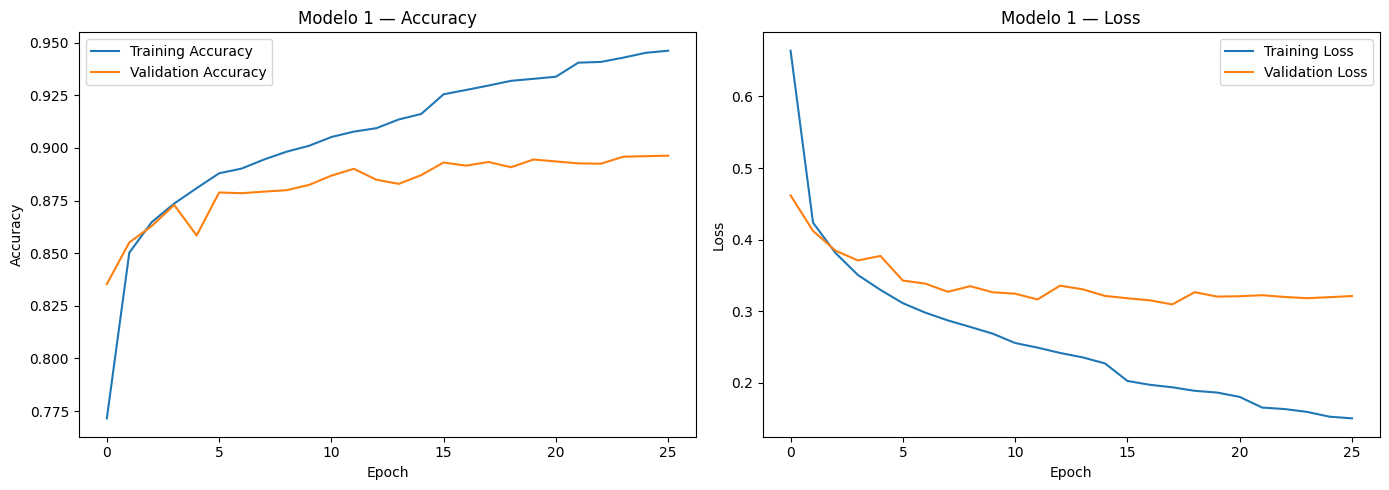

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history1.history['accuracy'], label='Training Accuracy')
ax1.plot(history1.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Modelo 1 — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history1.history['loss'], label='Training Loss')
ax2.plot(history1.history['val_loss'], label='Validation Loss')
ax2.set_title('Modelo 1 — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluación del modelo en el conjunto de prueba

Una vez finalizado el entrenamiento del modelo y analizado su comportamiento durante las épocas, es necesario evaluar su desempeño en **datos que el modelo no ha visto durante el entrenamiento**.

Para ello utilizaremos el conjunto de datos **X_test** y **y_test**, el cual fue separado previamente del dataset de entrenamiento.

Esta evaluación permitirá obtener una estimación más realista del **desempeño del modelo en datos nuevos**.

---

### Instrucciones

En la siguiente celda deberán:

1. Evaluar el modelo utilizando el método correspondiente de TensorFlow/Keras sobre **X_test** y **y_test**.
2. Obtener los valores de **loss** y **accuracy** del modelo en el conjunto de prueba.
3. Imprimir el valor de **accuracy** obtenido.

---

### Objetivo

El **test accuracy** representa la capacidad del modelo para **generalizar a datos no observados durante el entrenamiento**, por lo que constituye una métrica clave para comparar el desempeño entre los distintos modelos que se implementarán posteriormente.

---

👉 Implementar el código correspondiente en la siguiente celda.

In [15]:
test_loss1, test_acc1 = model1.evaluate(X_test, y_test, verbose=1)
print(f"Loss : {test_loss1}")
print(f"Accuracy : {test_acc1}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - accuracy: 0.8877 - loss: 0.3368
Loss : 0.3368246853351593
Accuracy : 0.8877000212669373


## Modelo 2 — MLP con Dropout

En esta sección se construirá un segundo modelo basado en una **red MLP (Multi-Layer Perceptron)** similar al modelo anterior, pero incorporando **Dropout** como técnica de regularización.

El objetivo es analizar cómo el uso de **Dropout** puede ayudar a mejorar la capacidad de generalización del modelo reduciendo el **overfitting**.

---

### Arquitectura del modelo

Se solicita construir una red neuronal con la siguiente estructura:

784 → 128 → 64 → 10

donde:

- **784** corresponde al número de características de entrada (28×28 píxeles).
- **128** y **64** corresponden a las capas ocultas.
- **10** corresponde al número de clases del dataset.

---

### ⚠️ Importante — Capa de entrada

Recordar que **784 no corresponde a una capa Dense**, sino al número de **features de entrada** del modelo.

Por lo tanto, este valor debe especificarse en la primera capa mediante el parámetro:

input_shape = (784,)


---

### Inicialización de pesos

Todas las capas densas deberán utilizar el inicializador:

RandomNormal(mean = 0.0 , stddev = 0.05)


---

### Regularización con Dropout

Para este modelo se solicita incorporar **Dropout** después de cada capa oculta.

Dropout consiste en **desactivar aleatoriamente un porcentaje de neuronas durante el entrenamiento**, lo que obliga al modelo a aprender representaciones más robustas y reduce la dependencia excesiva entre neuronas.

Seleccionar valores adecuados de **dropout rate** para cada capa.

---

### ⚠️ Selección de funciones de activación

Seleccionar cuidadosamente las **funciones de activación** para cada capa.

Recordar que:

- Las capas ocultas suelen utilizar **ReLU**
- La capa de salida debe utilizar una función adecuada para **clasificación multiclase**

---

### Entrenamiento del modelo

Entrenar el modelo utilizando los siguientes parámetros:

- **batch_size = 128**
- **validation_split = 0.2**
- **epochs = 500**

El historial del entrenamiento deberá almacenarse en la variable:

history2


---

### Callbacks

Se solicita implementar nuevamente los siguientes callbacks:

**EarlyStopping**

- monitorear: `val_loss`
- `patience = 8`
- `verbose = 1`
- restaurar los mejores pesos al finalizar el entrenamiento

**ReduceLROnPlateau**

- monitorear: `val_loss`
- `factor = 0.5`
- `patience = 3`
- `verbose = 1`

Estos callbacks permiten:

- detener el entrenamiento cuando el modelo deja de mejorar
- reducir automáticamente el learning rate cuando la pérdida de validación se estanca

---

👉 Implementar la arquitectura del modelo, compilarlo y entrenarlo en la siguiente celda.

In [16]:
#model2 = None
#history2 = None

#tf.keras.backend.clear_session() #limpia la memoria de la sesión actual
model2 = tf.keras.Sequential([
	tf.keras.layers.Dense(128, activation='relu',
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05),
							input_shape=(784,)),
    tf.keras.layers.Dropout(0.2),
	tf.keras.layers.Dense(64, activation='relu',
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05)),
    tf.keras.layers.Dropout(0.2),
	tf.keras.layers.Dense(10, activation='softmax', 
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05))
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
	monitor='val_loss',
	factor=0.5,
	patience=3,
	min_lr=1e-6,
	verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
	monitor='val_loss',
	patience=8, 
	restore_best_weights=True,
	verbose=1
)

history2 = model2.fit(
    X_train, y_train,
    epochs=500,
    batch_size = 128,
    validation_split = 0.2,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7303 - loss: 0.7503 - val_accuracy: 0.8272 - val_loss: 0.4901 - learning_rate: 0.0010
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8309 - loss: 0.4799 - val_accuracy: 0.8518 - val_loss: 0.4111 - learning_rate: 0.0010
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.8495 - loss: 0.4213 - val_accuracy: 0.8614 - val_loss: 0.3826 - learning_rate: 0.0010
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.8588 - loss: 0.3908 - val_accuracy: 0.8693 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.8653 - loss: 0.3738 - val_accuracy: 0.8706 - val_loss: 0.3567 - learning_rate: 0.0010
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - accuracy: 0.8721 - loss: 0.3539 - val_accuracy: 0.8768 - val_loss: 0.3417 - learning_rate: 0.0010
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.8738 

## Visualización del entrenamiento del Modelo 2

Una vez finalizado el entrenamiento del **Modelo 2**, es importante analizar el comportamiento del proceso de aprendizaje utilizando la información almacenada en:

history2


El objeto `history` contiene información sobre:

- **accuracy de entrenamiento**
- **accuracy de validación**
- **loss de entrenamiento**
- **loss de validación**

Estas métricas permiten evaluar si el modelo:

- está aprendiendo correctamente
- presenta **overfitting**
- presenta **underfitting**

---

### Instrucciones

En la siguiente celda deberán generar **una única figura de Matplotlib** que contenga **dos subgráficas**:

**1️⃣ Accuracy**

- Mostrar la curva de **training accuracy**
- Mostrar la curva de **validation accuracy**

**2️⃣ Loss**

- Mostrar la curva de **training loss**
- Mostrar la curva de **validation loss**

---

### Requisitos

- Utilizar **una sola figura** (`plt.figure`)
- Utilizar **dos subplots** para mostrar ambas gráficas
- Incluir **títulos en cada gráfica**
- Incluir **leyendas (legend)** para distinguir las curvas
- Etiquetar correctamente los ejes (`Epoch`, `Accuracy`, `Loss`)

Esto permitirá **comparar visualmente el comportamiento del Modelo 2 durante el entrenamiento**.

---

👉 Implementar el código correspondiente en la siguiente celda.

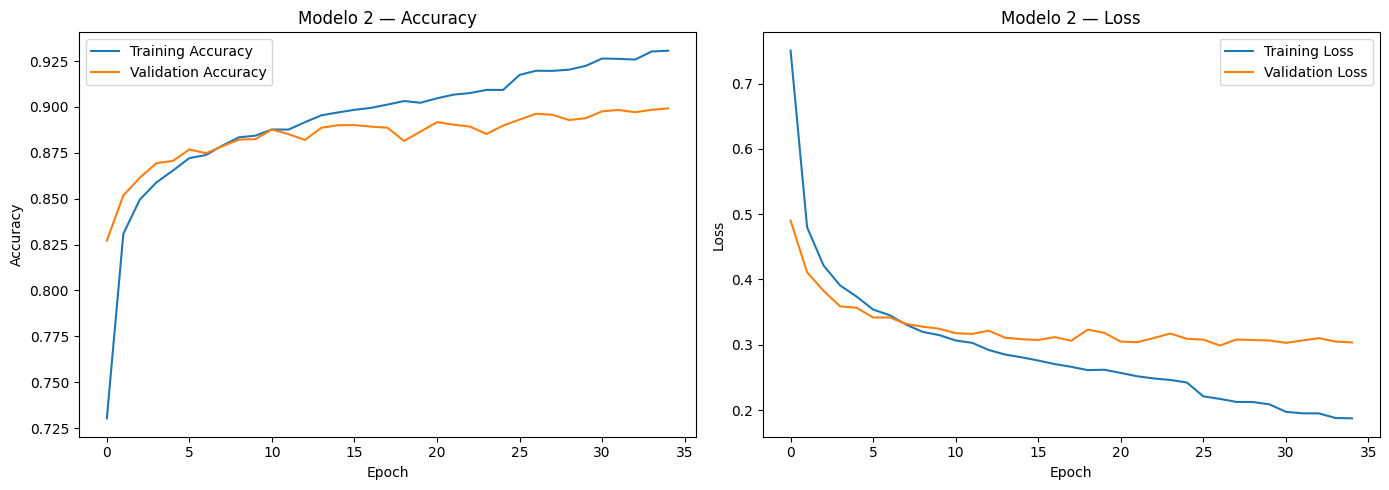

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history2.history['accuracy'], label='Training Accuracy')
ax1.plot(history2.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Modelo 2 — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history2.history['loss'], label='Training Loss')
ax2.plot(history2.history['val_loss'], label='Validation Loss')
ax2.set_title('Modelo 2 — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluación del Modelo 2 en el conjunto de prueba

Una vez finalizado el entrenamiento del **Modelo 2**, es necesario evaluar su desempeño utilizando el **conjunto de datos de prueba**.

Recordar que el conjunto **X_test** y **y_test** contiene datos que **no fueron utilizados durante el entrenamiento**, por lo que permite medir la capacidad de **generalización del modelo**.

---

### Instrucciones

En la siguiente celda deberán:

1. Evaluar el modelo utilizando **X_test** y **y_test**.
2. Obtener los valores de **loss** y **accuracy** en el conjunto de prueba.
3. Imprimir el valor de **accuracy** obtenido.

---

### Objetivo

El **test accuracy** permitirá comparar el desempeño de este modelo con el obtenido en el **Modelo 1**, y analizar si la incorporación de **Dropout como técnica de regularización** mejora la capacidad de generalización del modelo.

---

👉 Implementar el código correspondiente en la siguiente celda.

In [18]:
#test_loss2, test_acc2 = None, None

test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=1)
print(f"Loss : {test_loss2}")
print(f"Accuracy : {test_acc2}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - accuracy: 0.8914 - loss: 0.3274
Loss : 0.32735762000083923
Accuracy : 0.8913999795913696


## Modelo 3 — MLP con L2 y Dropout

En esta sección se construirá un tercer modelo basado en una **red MLP (Multi-Layer Perceptron)** que incorporará **dos técnicas de regularización**:

- **Regularización L2**
- **Dropout**

El objetivo es analizar si la combinación de ambas técnicas permite mejorar la **capacidad de generalización del modelo** y reducir el **overfitting** observado en modelos anteriores.

---

### Arquitectura del modelo

Se solicita construir una red neuronal con la siguiente estructura:

784 → 128 → 64 → 10

donde:

- **784** corresponde al número de características de entrada (28×28 píxeles).
- **128** y **64** corresponden a las capas ocultas.
- **10** corresponde al número de clases del dataset.

---

### ⚠️ Importante — Capa de entrada

Recordar que **784 no corresponde a una capa Dense**, sino al número de **features de entrada** del modelo.

Por lo tanto, este valor debe especificarse en la primera capa mediante el parámetro:

input_shape = (784,)


Esto indica que cada muestra de entrada es un **vector de 784 características**.

---

### Inicialización de pesos

Todas las capas densas deberán utilizar el inicializador:

RandomNormal(mean = 0.0 , stddev = 0.05)


Esto permite inicializar los pesos con valores pequeños distribuidos normalmente.

---

### Regularización L2

La regularización **L2** penaliza valores grandes en los pesos del modelo agregando un término adicional a la función de pérdida.

Esto ayuda a:

- reducir el **sobreajuste**
- mantener los pesos del modelo en magnitudes más controladas
- mejorar la capacidad de generalización

Se solicita aplicar **L2 regularization** en las capas densas ocultas.

---

### Regularización con Dropout

Además de L2, se deberá incluir **Dropout** después de cada capa oculta.

Dropout desactiva aleatoriamente un porcentaje de neuronas durante el entrenamiento, lo que obliga al modelo a **no depender excesivamente de neuronas específicas** y mejora la robustez del aprendizaje.

---

### ⚠️ Selección de funciones de activación

Seleccionar cuidadosamente las **funciones de activación** adecuadas para cada capa.

Recordar que:

- Las capas ocultas suelen utilizar **ReLU**
- La capa de salida debe utilizar una función adecuada para **clasificación multiclase**

---

### Entrenamiento del modelo

Entrenar el modelo utilizando los siguientes parámetros:

- **batch_size = 128**
- **validation_split = 0.2**
- **epochs = 500**

El historial del entrenamiento deberá almacenarse en la variable:

history3


---

### Callbacks

Se solicita implementar nuevamente los siguientes callbacks:

**EarlyStopping**

- monitorear: `val_loss`
- `patience = 8`
- `verbose = 1`
- restaurar los mejores pesos al finalizar el entrenamiento

**ReduceLROnPlateau**

- monitorear: `val_loss`
- `factor = 0.5`
- `patience = 3`
- `verbose = 1`

Estos callbacks permiten:

- detener el entrenamiento cuando el modelo deja de mejorar
- reducir automáticamente el learning rate cuando la pérdida de validación se estanca

---

👉 Implementar la arquitectura del modelo, compilarlo y entrenarlo en la siguiente celda.

In [19]:
#model3 = None
#history3 = None


#tf.keras.backend.clear_session() #limpia la memoria de la sesión actual
model3 = tf.keras.Sequential([
	tf.keras.layers.Dense(128, activation='relu',
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001),
							input_shape=(784,)),
    tf.keras.layers.Dropout(0.2),
	tf.keras.layers.Dense(64, activation='relu',
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
	tf.keras.layers.Dense(10, activation='softmax', 
							kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05))
])

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
	monitor='val_loss',
	factor=0.5,
	patience=3,
	min_lr=1e-6,
	verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
	monitor='val_loss',
	patience=8, 
	restore_best_weights=True,
	verbose=1
)

history3 = model3.fit(
    X_train, y_train,
    epochs=500,
    batch_size = 128,
    validation_split = 0.2,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7208 - loss: 0.9503 - val_accuracy: 0.8236 - val_loss: 0.6345 - learning_rate: 0.0010
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.8239 - loss: 0.6271 - val_accuracy: 0.8416 - val_loss: 0.5486 - learning_rate: 0.0010
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8364 - loss: 0.5730 - val_accuracy: 0.8436 - val_loss: 0.5307 - learning_rate: 0.0010
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.8424 - loss: 0.5474 - val_accuracy: 0.8567 - val_loss: 0.4979 - learning_rate: 0.0010
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.8488 - loss: 0.5234 - val_accuracy: 0.8589 - val_loss: 0.4908 - learning_rate: 0.0010
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step - accuracy: 0.8513 - loss: 0.5147 - val_accuracy: 0.8562 - val_loss: 0.4938 - learning_rate: 0.0010
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.8541 

## Visualización del entrenamiento del Modelo 3

Una vez finalizado el entrenamiento del **Modelo 3**, es importante analizar el comportamiento del proceso de aprendizaje utilizando la información almacenada en:

history3


El objeto `history` contiene información sobre:

- **accuracy de entrenamiento**
- **accuracy de validación**
- **loss de entrenamiento**
- **loss de validación**

Estas métricas permiten evaluar si el modelo:

- está aprendiendo correctamente
- presenta **overfitting**
- presenta **underfitting**

---

### Instrucciones

En la siguiente celda deberán generar **una única figura de Matplotlib** que contenga **dos subgráficas**:

**1️⃣ Accuracy**

- Mostrar la curva de **training accuracy**
- Mostrar la curva de **validation accuracy**

**2️⃣ Loss**

- Mostrar la curva de **training loss**
- Mostrar la curva de **validation loss**

---

### Requisitos

- Utilizar **una sola figura** (`plt.figure`)
- Utilizar **dos subplots** para mostrar ambas gráficas
- Incluir **títulos en cada gráfica**
- Incluir **leyendas (legend)** para distinguir las curvas
- Etiquetar correctamente los ejes (`Epoch`, `Accuracy`, `Loss`)

Esto permitirá **analizar el comportamiento del Modelo 3 durante el entrenamiento** y compararlo posteriormente con los modelos anteriores.

---

👉 Implementar el código correspondiente en la siguiente celda.

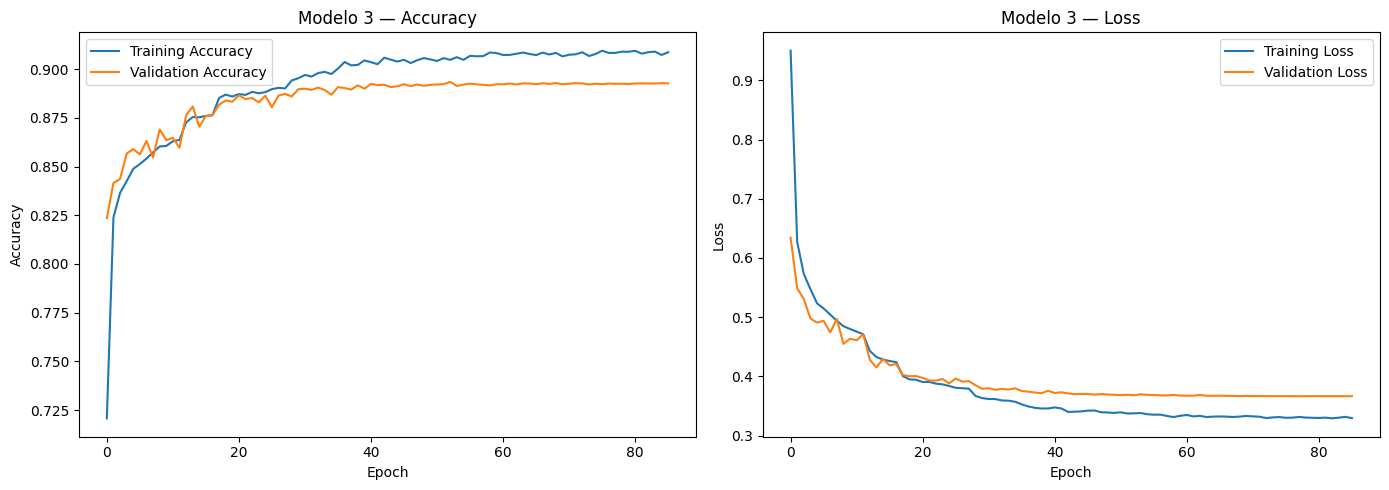

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history3.history['accuracy'], label='Training Accuracy')
ax1.plot(history3.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Modelo 3 — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history3.history['loss'], label='Training Loss')
ax2.plot(history3.history['val_loss'], label='Validation Loss')
ax2.set_title('Modelo 3 — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluación del Modelo 3 en el conjunto de prueba

Una vez finalizado el entrenamiento del **Modelo 3**, es necesario evaluar su desempeño utilizando el **conjunto de datos de prueba**.

Recordar que el conjunto **X_test** y **y_test** contiene datos que **no fueron utilizados durante el entrenamiento**, por lo que permite medir la capacidad de **generalización del modelo**.

---

### Instrucciones

En la siguiente celda deberán:

1. Evaluar el modelo utilizando **X_test** y **y_test**.
2. Obtener los valores de **loss** y **accuracy** en el conjunto de prueba.
3. Imprimir el valor de **accuracy** obtenido.

---

### Objetivo

El **test accuracy** permitirá comparar el desempeño de este modelo con los obtenidos en los **Modelos 1 y 2**, y analizar si la incorporación conjunta de **L2 y Dropout** logra mejorar la capacidad de generalización del modelo.

---

👉 Implementar el código correspondiente en la siguiente celda.

In [21]:
#test_loss3, test_acc3 = None, None

test_loss3, test_acc3 = model3.evaluate(X_test, y_test, verbose=1)
print(f"Loss : {test_loss3}")
print(f"Accuracy : {test_acc3}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - accuracy: 0.8861 - loss: 0.3889
Loss : 0.388916015625
Accuracy : 0.8860999941825867


## Modelo 4 — Red Convolucional (CNN)

Hasta este punto se han entrenado distintos modelos **MLP (Multi-Layer Perceptron)** utilizando los datos en formato vectorial. Sin embargo, este enfoque **pierde la estructura espacial de las imágenes**, ya que cada imagen fue convertida en un vector de 784 características.

Las **Redes Neuronales Convolucionales (CNN)** están diseñadas específicamente para trabajar con **datos de tipo imagen**, ya que permiten capturar **patrones espaciales como bordes, texturas y formas** mediante el uso de **capas convolucionales**.

Para poder utilizar una CNN, las imágenes deben tener la forma:

(altura, ancho, canales)

En el caso de **Fashion-MNIST**, cada imagen tiene dimensiones:

28 × 28

y al ser imágenes en **escala de grises**, el número de canales es:

1


Por lo tanto, las imágenes deberán tener la forma:

(28, 28, 1)


---

### Reformateo de las imágenes

Para adaptar los datos al formato requerido por una **CNN**, es necesario aplicar un **reshape** sobre los datasets de entrenamiento y prueba.

Este reshape transformará los datos desde:

(60000, 784)

a: 

(60000, 28, 28, 1)

y desde:

(10000, 784)

a:

(10000, 28, 28, 1)


---

### Instrucciones

En la siguiente celda se proporcionará el código necesario para realizar este **reshape de los datos**.

Por favor, **ejecutar la siguiente celda** antes de continuar con la construcción del modelo CNN.

In [22]:
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [23]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [24]:
print(X_train_cnn.shape)
print(X_test_cnn.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


## Entrenamiento del Modelo 4 — Convolutional Neural Network (CNN)

En este modelo se utilizará una **Red Neuronal Convolucional (CNN)** para realizar la clasificación de las imágenes del dataset **Fashion-MNIST**.

A diferencia de las redes **MLP**, las CNN están diseñadas específicamente para trabajar con datos de tipo imagen, ya que permiten **preservar la estructura espacial de los píxeles** y aprender automáticamente **patrones visuales relevantes**, tales como:

- bordes
- texturas
- formas
- patrones locales en la imagen

Esto se logra mediante el uso de **capas convolucionales**, que aplican filtros sobre las imágenes para extraer características importantes.

Posteriormente, las representaciones aprendidas por las capas convolucionales son procesadas por **capas densas**, las cuales realizan la clasificación final de la imagen.

En general, las **CNN suelen obtener mejores resultados que las redes MLP en problemas de visión por computadora**, debido a su capacidad para aprovechar la estructura bidimensional de las imágenes.

---

### Instrucciones

En la siguiente celda se proporciona la implementación del **modelo CNN completo**.

Se solicita **ejecutar la celda para entrenar el modelo** utilizando los mismos principios utilizados en los modelos anteriores, incluyendo:

- optimizador
- callbacks de entrenamiento
- almacenamiento del historial del entrenamiento

Este modelo servirá para **comparar el desempeño de una arquitectura convolucional frente a las redes MLP entrenadas anteriormente**.

---

👉 Ejecutar la siguiente celda para entrenar el modelo CNN.

In [25]:
initializer = RandomNormal(mean=0.0, stddev=0.05)

model4 = tf.keras.Sequential([
    layers.Conv2D(32, (3,3),activation='relu',kernel_initializer=initializer,input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3),activation='relu',kernel_initializer=initializer),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu',kernel_initializer=initializer),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax',kernel_initializer=initializer)

])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model4.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy", #sparse_categorical_crossentropy: Admite Entero (ej. 1)
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

history4 = model4.fit(
    X_train_cnn,y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/500


/Users/larenwell/Documents/personal/projects/ai-dl-tensorflow-specialization-fabricum-pucp/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7329 - loss: 0.7320 - val_accuracy: 0.8355 - val_loss: 0.4551 - learning_rate: 0.0010
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8340 - loss: 0.4550 - val_accuracy: 0.8620 - val_loss: 0.3771 - learning_rate: 0.0010
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8588 - loss: 0.3918 - val_accuracy: 0.8763 - val_loss: 0.3401 - learning_rate: 0.0010
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8723 - loss: 0.3516 - val_accuracy: 0.8850 - val_loss: 0.3129 - learning_rate: 0.0010
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8800 - loss: 0.3277 - val_accuracy: 0.8892 - val_loss: 0.3011 - learning_rate: 0.0010
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8870 - loss: 0.3106 - val_accuracy: 0.8898 - val_loss: 0.2970 - learning_rate: 0.0010
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8908 - loss: 0.2940 

## Visualización del entrenamiento del Modelo 4 (CNN)

Una vez finalizado el entrenamiento del **Modelo 4 basado en una CNN**, es importante analizar el comportamiento del proceso de aprendizaje utilizando la información almacenada en:

history4


Al igual que en los modelos anteriores, el objeto `history` contiene información sobre:

- **accuracy de entrenamiento**
- **accuracy de validación**
- **loss de entrenamiento**
- **loss de validación**

Estas métricas permiten observar cómo evoluciona el modelo durante el entrenamiento y analizar si el modelo presenta **overfitting**, **underfitting** o si logra **generalizar correctamente**.

---

### Instrucciones

En la siguiente celda deberán generar **una única figura de Matplotlib** que contenga **dos subgráficas**:

**1️⃣ Accuracy**

- Mostrar la curva de **training accuracy**
- Mostrar la curva de **validation accuracy**

**2️⃣ Loss**

- Mostrar la curva de **training loss**
- Mostrar la curva de **validation loss**

---

### Requisitos

- Utilizar **una sola figura** (`plt.figure`)
- Utilizar **dos subplots** para mostrar ambas gráficas
- Incluir **títulos en cada gráfica**
- Incluir **leyendas (legend)** para distinguir las curvas
- Etiquetar correctamente los ejes (`Epoch`, `Accuracy`, `Loss`)

Esto permitirá **analizar el comportamiento del modelo CNN durante el entrenamiento** y compararlo posteriormente con los modelos MLP implementados anteriormente.

---

👉 Implementar el código correspondiente en la siguiente celda.

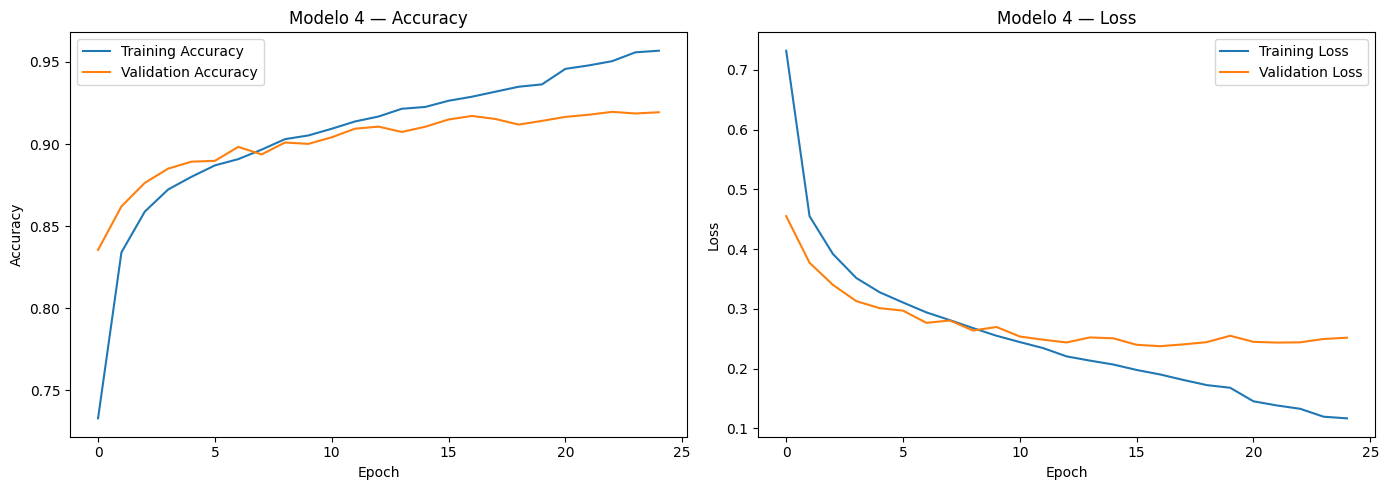

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history4.history['accuracy'], label='Training Accuracy')
ax1.plot(history4.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Modelo 4 — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history4.history['loss'], label='Training Loss')
ax2.plot(history4.history['val_loss'], label='Validation Loss')
ax2.set_title('Modelo 4 — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluación del Modelo 4 en el conjunto de prueba

Una vez finalizado el entrenamiento del **Modelo 4 basado en una Red Convolucional (CNN)**, es necesario evaluar su desempeño utilizando el **conjunto de datos de prueba**.

Recordar que el conjunto **X_test_cnn** y **y_test** contiene datos que **no fueron utilizados durante el entrenamiento**, por lo que permite medir la capacidad del modelo para **generalizar a nuevas muestras**.

---

### Instrucciones

En la siguiente celda deberán:

1. Evaluar el modelo utilizando **X_test_cnn** y **y_test**.
2. Obtener los valores de **loss** y **accuracy** en el conjunto de prueba.
3. Imprimir el valor de **accuracy** obtenido.

---

### Objetivo

El **test accuracy** permitirá comparar el desempeño del **modelo CNN** con los modelos **MLP entrenados anteriormente**.

En problemas de **clasificación de imágenes**, las CNN suelen obtener mejores resultados que las redes MLP, ya que son capaces de **capturar patrones espaciales presentes en las imágenes**.

---

👉 Implementar el código correspondiente en la siguiente celda.

In [27]:
#test_loss4, test_acc4 = None, None

test_loss4, test_acc4 = model4.evaluate(X_test_cnn, y_test, verbose=1)
print(f"Loss : {test_loss4}")
print(f"Accuracy : {test_acc4}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9104 - loss: 0.2525
Loss : 0.2525097131729126
Accuracy : 0.9103999733924866


## Comparación de desempeño entre los modelos

En esta sección se realizará una **comparación final entre los modelos entrenados**.

En la siguiente celda se imprimirán los valores de **accuracy obtenidos en el conjunto de prueba** para cada uno de los modelos entrenados anteriormente:

- **Modelo 1:** MLP básico  
- **Modelo 2:** MLP con Dropout  
- **Modelo 3:** MLP con L2 + Dropout  
- **Modelo 4:** CNN (Convolutional Neural Network)

Estos valores permiten observar cuál modelo logra **generalizar mejor en datos no vistos durante el entrenamiento**.

---

### Instrucciones

1️⃣ Ejecutar la siguiente celda para **imprimir los valores de accuracy** de cada modelo.

2️⃣ Luego, en la misma celda o en una nueva celda, escribir un **comentario en forma de string** donde se responda brevemente:

- ¿Cuál modelo obtuvo el **mejor desempeño** en el conjunto de prueba?
- ¿Las técnicas de **regularización (Dropout y L2)** ayudaron a mejorar el desempeño de los modelos MLP?
- ¿Cómo se compara el desempeño de los **modelos MLP** frente al **modelo CNN**?

3️⃣ Finalmente, comentar brevemente:

- ¿Qué **nuevas capas** aparecen en el modelo CNN que **no estaban presentes en los modelos MLP**?
- ¿Por qué estas capas pueden ayudar a mejorar el desempeño en problemas de **clasificación de imágenes**?

---

👉 Ejecutar la siguiente celda para visualizar los resultados y realizar el análisis correspondiente.

In [28]:
print("Modelo1:", test_acc1)
print("Modelo2:", test_acc2)
print("Modelo3:", test_acc3)
print("Modelo4:", test_acc4)

Modelo1: 0.8877000212669373
Modelo2: 0.8913999795913696
Modelo3: 0.8860999941825867
Modelo4: 0.9103999733924866
